In [175]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import datetime
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.meshed_domain as md
import src.models.mlp_model as mm

In [176]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [177]:
from typing import Tuple

In [178]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [179]:
# Problem parameters
RE = 1000
NU = 1 / RE

# domain bounds
L_BOUNDS = [0, 0]
U_BOUNDS = [1, 1]
# define grid sizes
Nx = 300
Ny = 300
dx = 1 / (Nx-1)
dy = 1 / (Ny-1)

In [180]:
mesh_ctx = md.MeshContext2D(
    Nx=100,
    Ny=100,
    device=device,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS
)

domain = md.MeshDomain2D(mesh_ctx)

In [181]:
def loss_fn(model: torch.nn.Module, domain: md.MeshDomain2D):
    # Get all points
    all_pts = domain.grid.requires_grad_(True)
    out = model(all_pts)
    u_vals, v_vals, p_vals = out[:, 0], out[:, 1], out[:, 2]
    
    # Compute values at meshes
    u_i_j, v_i_j, p_i_j = u_vals[domain.mesh_scheme[:, 0]], v_vals[domain.mesh_scheme[:, 0]], p_vals[domain.mesh_scheme[:, 0]]
    u_ip1_j, v_ip1_j, p_ip1_j = u_vals[domain.mesh_scheme[:, 1]], v_vals[domain.mesh_scheme[:, 1]], p_vals[domain.mesh_scheme[:, 1]]
    u_im1_j, v_im1_j, p_im1_j = u_vals[domain.mesh_scheme[:, 2]], v_vals[domain.mesh_scheme[:, 2]], p_vals[domain.mesh_scheme[:, 2]]
    u_i_jp1, v_i_jp1, p_i_jp1 = u_vals[domain.mesh_scheme[:, 3]], v_vals[domain.mesh_scheme[:, 3]], p_vals[domain.mesh_scheme[:, 3]]
    u_i_jm1, v_i_jm1, p_i_jm1 = u_vals[domain.mesh_scheme[:, 4]], v_vals[domain.mesh_scheme[:, 4]], p_vals[domain.mesh_scheme[:, 4]]

    # Compute differentials
    u_x, v_x, p_x = (u_ip1_j - u_im1_j) / (2 * dx), (v_ip1_j - v_im1_j) / (2 * dx), (p_ip1_j - p_im1_j) / (2 * dx)
    u_y, v_y, p_y = (u_i_jp1 - u_i_jm1) / (2 * dy), (v_i_jp1 - v_i_jm1) / (2 * dy), (p_i_jp1 - p_i_jm1) / (2 * dy)
    u_xx, v_xx = (u_ip1_j + u_im1_j - 2 * u_i_j) / (dx**2), (v_ip1_j + v_im1_j - 2 * v_i_j) / (dx**2)
    u_yy, v_yy = (u_i_jp1 + u_i_jm1 - 2 * u_i_j) / (dy**2), (u_i_jp1 + u_i_jm1 - 2 * u_i_j) / (dy**2)
    
    # Compute residuals
    res_a = u_i_j * u_x + v_i_j * u_y + p_x - NU * (u_xx + u_yy)
    res_b = u_i_j * v_x + v_i_j * v_y + p_y - NU * (v_xx + v_yy)
    res_c = u_x + v_y

    # Compute interior loss
    int_loss = torch.mean(res_a**2 + res_b**2 + res_c**2)
    
    # Compute top loss
    top_pts = domain.boundaries[3].requires_grad_(True)
    out_top = model(top_pts)
    u_top, v_top = out_top[:, 0], out_top[:, 1]
    top_loss = torch.mean((u_top - 1)**2 + v_top**2)
    
    # Compute side loss
    side_pts = torch.cat([domain.boundaries[0], domain.boundaries[1], domain.boundaries[2]], dim=0).requires_grad_(True)
    out_side = model(side_pts)
    u_side, v_side = out_side[:, 0], out_side[:, 1]
    side_loss = torch.mean(u_side**2 + v_side**2)
    
    return [int_loss, top_loss, side_loss]

In [182]:
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=3,
    layer=[32, 32, 32, 32],
    u_bounds=U_BOUNDS,
    l_bounds=L_BOUNDS
)

model = mm.MLPModel(model_ctx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [185]:
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=loss_fn,
    epochs=40_000,
    monitor_gradient=True
)

total_loss_A, comp_loss_A = train.simple_train(train_ctx)

Loss at epoch 1 is: 0.09635093808174133. Total gradient norm: 0.10660226313531337 
Loss at epoch 100 is: 0.08152447640895844. Total gradient norm: 0.08989655256995298 
Loss at epoch 200 is: 0.07161243259906769. Total gradient norm: 0.0764278873656674 
Loss at epoch 300 is: 0.06623255461454391. Total gradient norm: 0.08822786486090656 
Loss at epoch 400 is: 0.06242792680859566. Total gradient norm: 0.04157439699107095 
Loss at epoch 500 is: 0.05890946090221405. Total gradient norm: 0.03950618916956001 
Loss at epoch 600 is: 0.0554267093539238. Total gradient norm: 0.2614783432855363 
Loss at epoch 700 is: 0.05192774906754494. Total gradient norm: 0.036528389800150135 
Loss at epoch 800 is: 0.04847953841090202. Total gradient norm: 0.050643160894559364 
Loss at epoch 900 is: 0.04519681632518768. Total gradient norm: 0.03347834515322795 
Loss at epoch 1000 is: 0.04208464175462723. Total gradient norm: 0.07937634776873424 
Loss at epoch 1100 is: 0.039273202419281006. Total gradient norm: 0

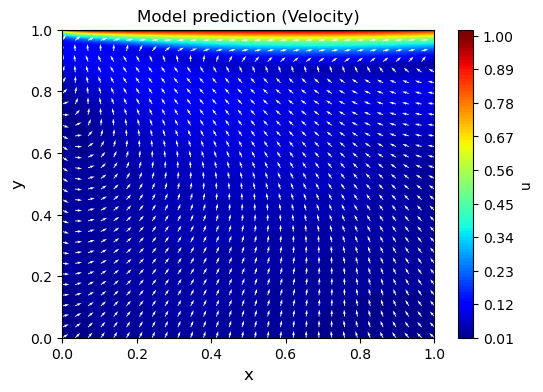

In [186]:
# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = ['u'],
    titles= ['Model prediction (Velocity)'],
    device=device,
    vmin=0,
    vmax=1,
    patches=[],
    N = 100
)

# 
def velocity(x: torch.Tensor) -> torch.Tensor:
    x.requires_grad_(True)
    out = model(x)
    u = out[:, 0:1]
    v = out[:, 1:2]
    
    return torch.cat([u, v], dim=1)

utils.plot_vector_field_2d([velocity], plot_ctx, N=100, n_width=30, n_heigth=30)

plot_ctx.vmin=-0.53
plot_ctx.vmax=-0.43
plot_ctx.titles = ['Model prediction (Streamfunction)']
plot_ctx.function_names = [r'$\psi$']

#utils.plot_function_on_2d_cube([lambda x: model(x)[:, 0]], plot_ctx)

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


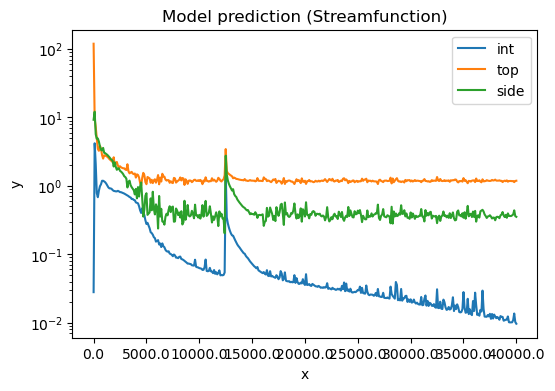

In [187]:
utils.plot_loss_values({"int": comp_loss[0], "top": comp_loss[1], "side": comp_loss[2]}, plot_ctx)